## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy

### Name: Freddy Silva, César Cruz, Fernando Guevara, Kailin Wu
### IDs: A00828792, A00825747, A00828723, A00830574
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [1]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file
Defines the path to the GloVe embeddings file and provides a function to parse it into a word-to-vector dictionary. To save time, the dictionary is loaded from a .pkl file instead of re-parsing the raw text file on every run.

In [2]:
# Active path to the GloVe pre-trained word embeddings file
PATH = '../../embeddings/glove.6B.200d.txt'

# Defines the size of each word embedding vector
emb_dim = 200

In [3]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    """
    Reads the file and builds a word-to-vector dictionary

    Args:
        path (str): Path to the text file
    
    Returns:
        embeddings: A dictionary mapping each word to its embedding vector

    """
    
    # Initialize empty dictionary to store word
    embeddings = {}
    
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()   # Split each line into individual value
            word = values[0]    # First value is the word
            vector = np.array(values[1:], dtype=np.float32) # Remaining values form the embedding vector
            embeddings[word] = vector   # Map the word to its vector
    
    return embeddings

In [4]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [5]:
# # Serialize
# with open('../../serialize/embeddings_dict_200D.pkl', 'wb') as f:
#     pickle.dump(embeddings_dict, f)

# Deserialize
with open('../../serialize/embeddings_dict_200D.pkl', 'rb') as f:
    embeddings_dict = pickle.load(f)

#### See some embeddings

Defines a funtion to quickly inspect the embeddings file by printing first n words along with the size of their vectors. It's then called to preview the first 5 entries as a sanity check.

In [6]:
# Show some words
def show_n_first_words(path, n_words):
        """
        Prints the first n words and their embedding vector length.

        Args:
            path (str): Path to the text file.
            n_words (int): Number of words to display.
        """
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))  # Print word + its vector dimension count
                if i>=n_words: break    # Stop after reaching the desired number of words

In [7]:
# Calls the function to print the first 5 entries from the GloVe file
show_n_first_words(PATH, 5)

['the', '-0.071549', '0.093459', '0.023738', '-0.090339', '0.056123', '0.32547', '-0.39796', '-0.092139', '0.061181', '-0.1895', '0.13061', '0.14349', '0.011479', '0.38158', '0.5403', '-0.14088', '0.24315', '0.23036', '-0.55339', '0.048154', '0.45662', '3.2338', '0.020199', '0.049019', '-0.014132', '0.076017', '-0.11527', '0.2006', '-0.077657', '0.24328', '0.16368', '-0.34118', '-0.06607', '0.10152', '0.038232', '-0.17668', '-0.88153', '-0.33895', '-0.035481', '-0.55095', '-0.016899', '-0.43982', '0.039004', '0.40447', '-0.2588', '0.64594', '0.26641', '0.28009', '-0.024625', '0.63302', '-0.317', '0.10271', '0.30886', '0.097792', '-0.38227', '0.086552', '0.047075', '0.23511', '-0.32127', '-0.28538', '0.1667', '-0.0049707', '-0.62714', '-0.24904', '0.29713', '0.14379', '-0.12325', '-0.058178', '-0.001029', '-0.082126', '0.36935', '-0.00058442', '0.34286', '0.28426', '-0.068599', '0.65747', '-0.029087', '0.16184', '0.073672', '-0.30343', '0.095733', '-0.5286', '-0.22898', '0.064079', '0.0

### Plot some embeddings
Defines a flexible function that takes a list of words, retrieves their high-dimensional vectors, reduces them to 2D using either PCA or t-SNE, and plots them as a labeled scatter chart. It's then called twice, once with PCA and once with t-SNE, to visually compare how both methods cluster semantically related words.

In [8]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):
    """
    Reduces high-dimensional word embeddings to 2D and plots them as a scatter plot.

    Args:
        emb_path (str): Path to the embeddings file.
        words2show (list): List of words to visualize.
        emb_dim (int): Dimensionality of the original embedding vectors.
        embeddings_dict (dict): Dictionary mapping words to their embedding vectors.
        func (class, optional): Dimensionality reduction method to use. Defaults to PCA.

    Returns:
        None: Displays a 2D scatter plot with each word labeled at its reduced position.
    """

    # Filter only valid words
    valid_words = [w for w in words2show if w in embeddings_dict]

    # Matrix built up
    if len(valid_words) == 0:
        print("No valid words found in embeddings.")
        return
    
    # Stack the embedding vectors for all valid words into a 2D array
    vectors = np.array([embeddings_dict[w] for w in valid_words])
    
    # Reduce dimensionality
    if func == PCA:
        reducer = PCA(n_components=2)
    elif func == TSNE:
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = func(n_components=2)
    
    # Apply the chosen reducer to transform vectors from high-D to 2D
    reduced = reducer.fit_transform(vectors)
    
    # Plot the 2D scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:, 0], reduced[:, 1])
    
    # Annotate each point with its corresponding word label
    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))
    
    # Set the title dynamically using the reducer name and original embedding dimensions
    plt.title(f"{func.__name__} Visualization ({emb_dim}D → 2D)")
    plt.show()

In [9]:
# Defines a set of semantically diverse words across categories
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


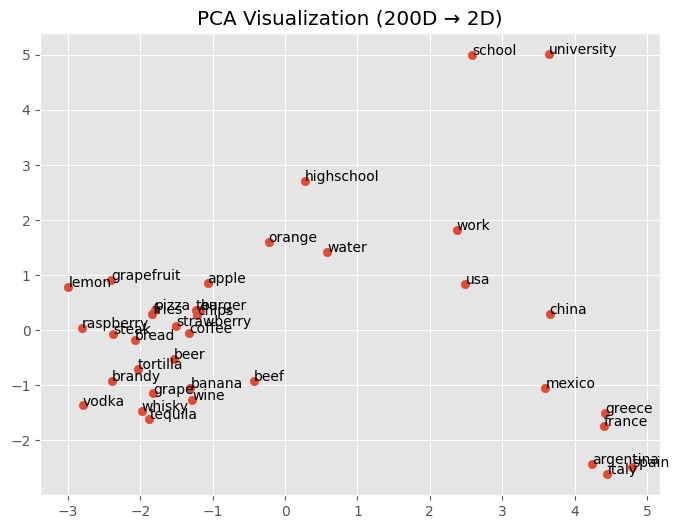

In [10]:
# Plots the word embeddings reduced to 2D using PCA
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

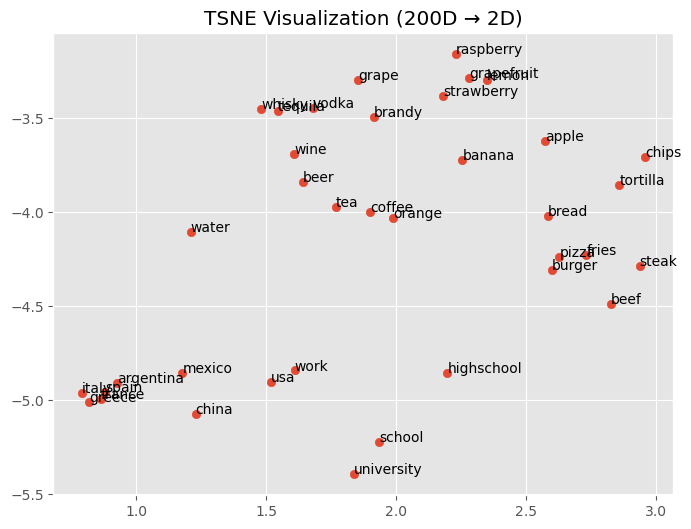

In [11]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Let us compute analogies
It implements two core NLP operations using cosine similarity. The analogy function solves word analogies via vector arithmetic, while find_most_similar retrieves the closest words to a given query word. Both rely on a shared helper function that measures the angular similarity between two embedding vectors.

In [12]:
# Helper cosine function for vector similarity
def cosine_similarity(vec1, vec2):
    """
    Computes the cosine similarity between two vectors

    Args:
        vec1 (np.ndarray): First embedding vector.
        vec2 (np.ndarray): Second embedding vector.

    Returns:
        float: Cosine similarity score between -1 and 1.
    """
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [13]:
# Analogy
def analogy(word1, word2, word3, embeddings_dict):
    """
    Solves the word analogies of the form: word1 is to word2 as word3 is to __?
    Uses vector arithmetic: target = vec(word2) - vec(word1) + vec(word3).

    Args:
        word1 (str): The base word.
        word2 (str): The transformed word.
        word3 (str): The query word.
        embeddings_dict (dict): Dictionary mapping words to their embedding vectors.

    Returns:
        tuple: The best matching word and its similarity socre.
    """
    
    # Validate the words exist in the embeddings dictionary
    for w in [word1, word2, word3]:
        if w not in embeddings_dict:
            print(f"{w} not found in vocabulary.")
            return None
    
    # Compute the target vector using analogy arithmetic
    target_vector = (
        embeddings_dict[word2]
        - embeddings_dict[word1]
        + embeddings_dict[word3]
    )
    
    similarities = []
    
    # Compare target vector against every word in the vocabulary
    for word, vector in embeddings_dict.items():
        
        # Skip the input words to avoid returning them as results
        if word in [word1, word2, word3]:
            continue
        
        # Compute cosine similarity between the target and current word vector
        sim = cosine_similarity(target_vector, vector)
        similarities.append((word, sim))
    
    # Sort results by similarity score in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Return best match
    return similarities[0]

In [18]:
# Solves: man -> king, as woman -> ?
analogy('man', 'king', 'woman', embeddings_dict)

('queen', 0.71191645)

In [15]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    """
    Finds the top N most similar words to a given word using cosine similarity.

    Args:
        word (str): The query word to find similar words for.
        embeddings_dict (dict): Dictionary mapping words to their embedding vectors.
        top_n (int, optional): Number of top similar words to return. Defaults to 10.

    Returns:
        list: A list of tuples sorted by descending similarity.
    """
    
    # Validate that the query word exists in the embeddings dictionary
    if word not in embeddings_dict:
        print(f"{word} not found in vocabulary.")
        return None
    
    # Retrieve the vector for the query word
    word_vector = embeddings_dict[word]
    similarities = []
    
    # Compare the query word vector against every other word in the vocabulary
    for other_word, other_vector in embeddings_dict.items():
        
        # Skip query word itself
        if other_word == word:
            continue
        
        # Compute cosine similarity and store the result
        sim = cosine_similarity(word_vector, other_vector)
        similarities.append((other_word, sim))
    
    # Sort by similarity score in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Return only top N results
    return similarities[:top_n]

In [16]:
# Retrives the 10 words most similar to mexico
most_similar = find_most_similar('mexico', embeddings_dict)

In [19]:
# Print the ranked results
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> guatemala
6 ---> argentina
7 ---> brazil
8 ---> chile
9 ---> bolivia
10 ---> america


### Conclusion

In this activity, we explored how **GloVe embeddings** represent words as dense vectors that preserve semantic relationships. By creating the embeddings dictionary and saving it as a serialized file, we made the workflow more efficient and reused the data without rebuilding the dictionary every time.

Through the **PCA** and **t-SNE** visualizations, we observed that several words were grouped according to their meaning. For example, countries such as *Spain, Italy, France, Greece, Argentina,* and *Mexico* appeared close to one another, while food-related words such as *pizza, burger, fries, tortilla, steak,* and *beef* also formed visible clusters. We also noticed that words related to education, such as *school, university,* and *highschool*, stayed relatively close in the reduced space.

The results from the similarity and analogy tasks also supported the quality of the embeddings. In the analogy example, the model returned **queen** for the relation *man : king :: woman : ?*, with a similarity score of approximately **0.712**. In the similarity task, the words closest to *mexico* included **mexican, venezuela, colombia, peru, guatemala, argentina, brazil, chile, bolivia,** and **america**, which shows that the embeddings capture meaningful geographic and semantic associations.

Overall, we conclude that this notebook met the objectives of the activity. We were able to use pretrained embeddings to visualize semantic structure, identify similar words, and solve analogies using **NumPy-based operations**, which demonstrates the practical value of word embeddings in natural language processing.